In [15]:
# CALE and UNLE visualization
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CALE_PATH = "../results/f2_gompertz/table/gompertz_derived_metrics_by_country.csv"
GLOBAL_METRICS_PATH = "../results/f2_gompertz/table/global_popweight_metrics.csv"
LAST_SURVEY_YEAR_PATH = "../results/model_prep/last_survey_year_by_country.csv"
WB_UNLE_PATH = "../data/wb/wb_life_expectancy_2010_2025.csv"
WB_UNLE_FALLBACK_PATH = "../data/wb/wb_life_expectancy_last_survey_year.csv"
WBLE_XLSX_PATH = "../data/wb/WBLE.xlsx"
ISO_CSV_PATH = "../data/iso40.csv"
OUT_DIR = "../results/f3_CALE"

START_AGE = 50
DPI_OUT = 600
FONT_SIZE = 9

ALIASES = {
    "czechia": "czech republic",
    "united states": "usa",
    "united kingdom": "england",
    "netherlands (kingdom of the)": "netherlands",
    "korea, rep.": "korea",
    "slovak republic": "slovakia",
}

def normalize_country(val):
    if isinstance(val, pd.Series):
        s = val.astype(str).str.strip().str.lower()
        return s.replace(ALIASES)
    key = str(val).strip().lower()
    return ALIASES.get(key, key)

def load_iso_map(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    cols_l = {c.lower(): c for c in df.columns}

    iso_num_col = cols_l.get("isocountry") or cols_l.get("iso3_num") or cols_l.get("iso3num") or cols_l.get("iso_num")
    name_col = cols_l.get("isocountry_c") or cols_l.get("country") or cols_l.get("country_name") or cols_l.get("countryname")
    iso3_col = cols_l.get("iso3c") or cols_l.get("iso3")

    if iso_num_col is None or name_col is None or iso3_col is None:
        raise ValueError(f"Missing columns in iso.csv. Columns: {df.columns.tolist()}")

    out = df[[iso_num_col, name_col, iso3_col]].copy()
    out[iso_num_col] = pd.to_numeric(out[iso_num_col], errors="coerce").astype("Int64")
    out = out.dropna(subset=[iso_num_col, name_col])
    out["Country"] = out[name_col].astype(str).str.strip()
    out["iso3_num"] = out[iso_num_col].astype("Int64").astype(str)
    out["ISO3"] = out[iso3_col].astype(str).str.strip().str.upper()
    return out[["iso3_num", "Country", "ISO3"]]

def load_wb_unle(path: str) -> pd.DataFrame:
    if not os.path.exists(path) and os.path.exists(WB_UNLE_FALLBACK_PATH):
        print(f"WB_UNLE_PATH not found, using fallback: {WB_UNLE_FALLBACK_PATH}")
        path = WB_UNLE_FALLBACK_PATH
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    cols_l = {c.lower(): c for c in df.columns}

    country_col = cols_l.get("isocountry_c") or cols_l.get("country") or cols_l.get("country_name")
    year_col = cols_l.get("year")
    le_col = cols_l.get("le") or cols_l.get("life_expectancy")
    iso3_col = cols_l.get("iso3c") or cols_l.get("iso3")

    if country_col is None or year_col is None or le_col is None:
        raise ValueError(f"Missing columns in WB data. Columns: {df.columns.tolist()}")

    keep_cols = [country_col, year_col, le_col]
    if iso3_col is not None:
        keep_cols.append(iso3_col)
    out = df.loc[:, keep_cols].copy()
    out = out.rename(columns={country_col: "Country", year_col: "year", le_col: "UNLE"})
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["UNLE"] = pd.to_numeric(out["UNLE"], errors="coerce")
    out["Country"] = out["Country"].astype(str).str.strip()
    out["country_norm"] = normalize_country(out["Country"])
    if iso3_col is not None:
        out = out.rename(columns={iso3_col: "ISO3"})
        out["ISO3"] = out["ISO3"].astype(str).str.strip().str.upper()
    return out.dropna(subset=["Country", "year", "UNLE"])

def get_global_unle(wb_df: pd.DataFrame, year: int = 2023) -> float:
    sub = wb_df.loc[wb_df["year"] == year].copy() if "year" in wb_df.columns else pd.DataFrame()
    if not sub.empty and "ISO3" in sub.columns:
        wld = sub.loc[sub["ISO3"].astype(str).str.upper() == "WLD", "UNLE"]
        if not wld.empty:
            return float(wld.iloc[0])
    if not sub.empty and "country_norm" in sub.columns:
        for name in ["world", "global"]:
            w = sub.loc[sub["country_norm"] == name, "UNLE"]
            if not w.empty:
                return float(w.iloc[0])

    # The last-survey-year WB file contains only study countries, so use WBLE.xlsx for World.
    if os.path.exists(WBLE_XLSX_PATH):
        wble = pd.read_excel(WBLE_XLSX_PATH)
        wble.columns = [str(c).strip() for c in wble.columns]
        country_col = "Country Name" if "Country Name" in wble.columns else None
        code_col = "Country Code" if "Country Code" in wble.columns else None
        year_cols = [c for c in wble.columns if str(c).isdigit()]
        if year_cols:
            year_col = str(year) if str(year) in year_cols else sorted(year_cols)[-1]
            mask = pd.Series(False, index=wble.index)
            if country_col is not None:
                mask = mask | wble[country_col].astype(str).str.strip().str.lower().eq("world")
            if code_col is not None:
                mask = mask | wble[code_col].astype(str).str.strip().str.upper().eq("WLD")
            vals = pd.to_numeric(wble.loc[mask, year_col], errors="coerce").dropna()
            if not vals.empty:
                return float(vals.iloc[0])
    return np.nan

os.makedirs(OUT_DIR, exist_ok=True)
print("Output dir:", OUT_DIR)

Output dir: ../results/f3_CALE


In [16]:
# Load ISO mapping (numeric + alpha)
iso_map = load_iso_map(ISO_CSV_PATH)
print("ISO rows:", len(iso_map))
print(iso_map.head())

ISO rows: 40
  iso3_num    Country ISO3
0       36  Australia  AUS
1       40    Austria  AUT
2       56    Belgium  BEL
3       76     Brazil  BRA
4      100   Bulgaria  BGR


WB_UNLE_PATH not found, using fallback: ../data/wb/wb_life_expectancy_last_survey_year.csv
Missing in last_survey_year: 0
Missing in WB life expectancy: 4


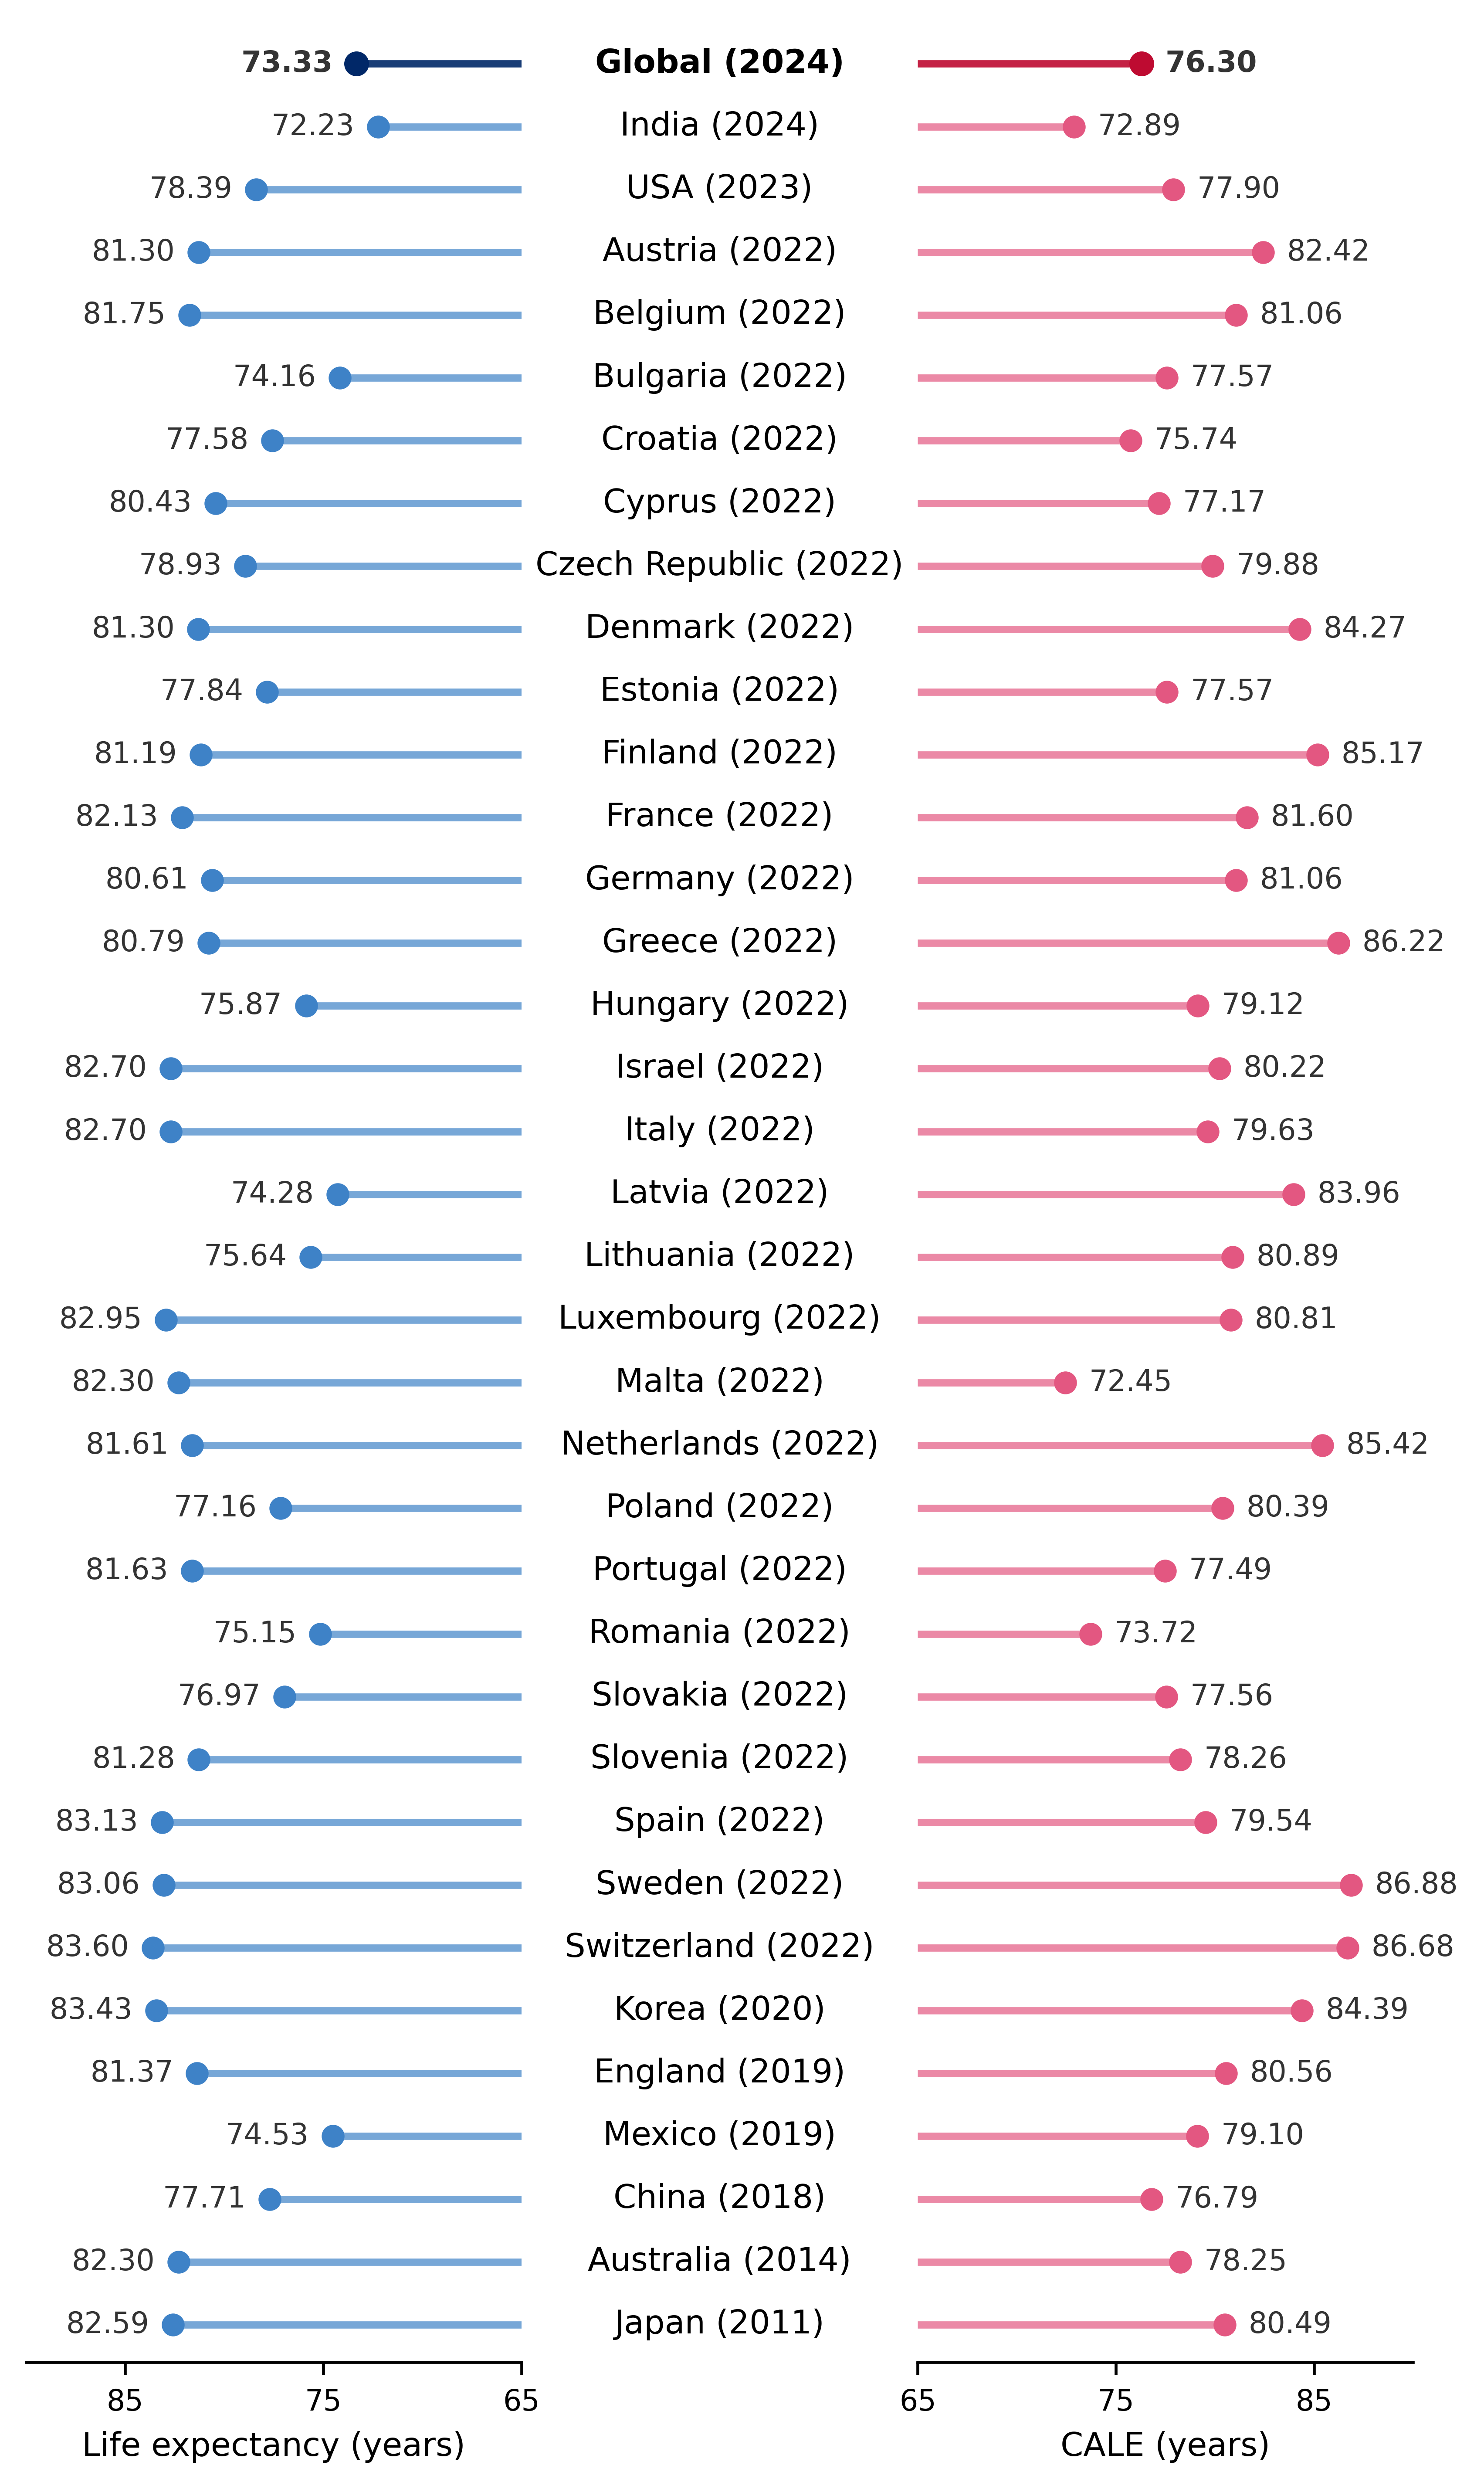

Saved: ../results/f3_CALE/cale_unle_lollipop_updown.pdf


In [17]:
# CALE right + country names (middle) + UNLE left lollipop
from matplotlib.ticker import FuncFormatter

cale = pd.read_csv(CALE_PATH)
cale = cale.rename(columns={"rmst": "CALE", "country": "Country"})
cale = cale[["Country", "CALE"]].dropna()
cale["Country"] = cale["Country"].astype(str).str.strip()
cale["country_norm"] = normalize_country(cale["Country"])

last_year = pd.read_csv(LAST_SURVEY_YEAR_PATH)
last_year["country_norm"] = normalize_country(last_year["country"])
last_year["last_survey_year"] = pd.to_numeric(last_year["last_survey_year"], errors="coerce").astype("Int64")
wb = load_wb_unle(WB_UNLE_PATH)

missing_last = cale.loc[~cale["country_norm"].isin(last_year["country_norm"]), "Country"].drop_duplicates().sort_values()
missing_wb = last_year.loc[~last_year["country_norm"].isin(wb["country_norm"]), "country"].drop_duplicates().sort_values()
print("Missing in last_survey_year:", len(missing_last))
print("Missing in WB life expectancy:", len(missing_wb))

merged = cale.merge(last_year[["country_norm", "last_survey_year"]], on="country_norm", how="inner")
merged = merged.merge(
    wb[["country_norm", "year", "UNLE"]],
    left_on=["country_norm", "last_survey_year"],
    right_on=["country_norm", "year"],
    how="inner",
)
merged = merged.drop(columns=["year"])
merged["survey_year"] = merged["last_survey_year"].astype("Int64")

# Add Global (CALE from global_popweight_metrics.csv; UNLE from WB 2024)
global_cale = np.nan
if os.path.exists(GLOBAL_METRICS_PATH):
    global_metrics = pd.read_csv(GLOBAL_METRICS_PATH)
    global_mask = global_metrics["country"].astype(str).str.strip().str.lower() == "global"
    if global_mask.any():
        global_cale = pd.to_numeric(global_metrics.loc[global_mask, "rmst"], errors="coerce").iloc[0]
global_unle = get_global_unle(wb, year=2024)
if np.isfinite(global_cale) and np.isfinite(global_unle):
    global_row = pd.DataFrame([{
        "Country": "Global",
        "CALE": float(global_cale),
        "UNLE": float(global_unle),
        "country_norm": "global",
        "last_survey_year": 2024,
        "survey_year": 2024,
    }])
    merged = pd.concat([global_row, merged], ignore_index=True)

merged = merged.sort_values(["survey_year", "Country"], ascending=[False, True]).reset_index(drop=True)
global_idx = merged["Country"].astype(str).str.lower() == "global"
if global_idx.any():
    global_row = merged.loc[global_idx]
    merged = pd.concat([global_row, merged.loc[~global_idx]], ignore_index=True)
merged["display_name"] = merged["Country"].astype(str).str.strip() + " (" + merged["survey_year"].astype(int).astype(str) + ")"

names = merged["display_name"].tolist()
y_pos = np.arange(len(names))

BASE_AGE = 65
Y_RANGE = (65, 90)
Y_TICKS = [65, 75, 85]
LABEL_OFFSET = 1.2
LINE_WIDTH = 2.0
POINT_SIZE = 28

LOLLIPOP_COLOR_CALE = "#e35781"
LOLLIPOP_COLOR_UNLE = "#3e82c7"
GLOBAL_COLOR_CALE = "#BE0B31"
GLOBAL_COLOR_UNLE = "#012868"

fig_h = max(6.5, 0.26 * len(names))
fig = plt.figure(figsize=(5.8, fig_h), dpi=DPI_OUT)
fig.patch.set_facecolor("none")
fig.patch.set_alpha(0.0)
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 0.8, 1.0], wspace=0.0)
ax_left = fig.add_subplot(gs[0, 0])
ax_mid = fig.add_subplot(gs[0, 1], sharey=ax_left)
ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)
ax_left.set_facecolor("none")
ax_mid.set_facecolor("none")
ax_right.set_facecolor("none")

cale_vals = merged["CALE"].values
unle_vals = merged["UNLE"].values
unle_offset = unle_vals - BASE_AGE
global_mask = merged["Country"].astype(str).str.lower() == "global"

# Right: CALE (from BASE_AGE)
ax_right.hlines(y=y_pos[~global_mask], xmin=BASE_AGE, xmax=cale_vals[~global_mask], color=LOLLIPOP_COLOR_CALE, alpha=0.7, linewidth=LINE_WIDTH)
ax_right.scatter(cale_vals[~global_mask], y_pos[~global_mask], color=LOLLIPOP_COLOR_CALE, s=POINT_SIZE, zorder=3)
if global_mask.any():
    ax_right.hlines(y=y_pos[global_mask], xmin=BASE_AGE, xmax=cale_vals[global_mask], color=GLOBAL_COLOR_CALE, alpha=0.9, linewidth=LINE_WIDTH)
    ax_right.scatter(cale_vals[global_mask], y_pos[global_mask], color=GLOBAL_COLOR_CALE, s=POINT_SIZE + 6, zorder=4)
ax_right.set_ylim(len(names) - 0.4, -0.6)
ax_right.set_xlim(*Y_RANGE)
ax_right.set_xticks(Y_TICKS)
ax_right.tick_params(axis="y", labelleft=False)
ax_right.tick_params(axis="x", labelsize=FONT_SIZE - 1)
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)
ax_right.spines["left"].set_visible(False)
ax_right.set_xlabel("CALE (years)", fontsize=FONT_SIZE)

for idx, name in enumerate(names):
    weight = "bold" if str(merged.loc[idx, "Country"]).strip().lower() == "global" else "normal"
    ax_right.text(cale_vals[idx] + LABEL_OFFSET, y_pos[idx], f"{cale_vals[idx]:.2f}", ha="left", va="center", fontsize=FONT_SIZE - 1, color="#333333", fontweight=weight)

# Middle: Country names (horizontal order)
ax_mid.set_xlim(-1.6, 1.6)
ax_mid.set_xticks([])
ax_mid.set_yticks([])
ax_mid.spines[:].set_visible(False)
for y, name in zip(y_pos, names):
    weight = "bold" if str(name).strip().lower().startswith("global") else "normal"
    ax_mid.text(0, y, name, ha="center", va="center", fontsize=FONT_SIZE, fontweight=weight)

# Left: UNLE (from BASE_AGE, show positive tick labels)
ax_left.hlines(y=y_pos[~global_mask], xmin=0, xmax=-unle_offset[~global_mask], color=LOLLIPOP_COLOR_UNLE, alpha=0.7, linewidth=LINE_WIDTH)
ax_left.scatter(-unle_offset[~global_mask], y_pos[~global_mask], color=LOLLIPOP_COLOR_UNLE, s=POINT_SIZE, zorder=3)
if global_mask.any():
    ax_left.hlines(y=y_pos[global_mask], xmin=0, xmax=-unle_offset[global_mask], color=GLOBAL_COLOR_UNLE, alpha=0.9, linewidth=LINE_WIDTH)
    ax_left.scatter(-unle_offset[global_mask], y_pos[global_mask], color=GLOBAL_COLOR_UNLE, s=POINT_SIZE + 6, zorder=4)
ax_left.set_ylim(len(names) - 0.4, -0.6)
ax_left.set_xlim(-(Y_RANGE[1] - BASE_AGE), 0)
ax_left.set_xticks([-(t - BASE_AGE) for t in Y_TICKS])
ax_left.tick_params(axis="y", labelleft=False)
ax_left.tick_params(axis="x", labelsize=FONT_SIZE - 1)
ax_left.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{BASE_AGE + abs(x):g}"))
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.spines["left"].set_visible(False)
ax_left.set_xlabel("Life expectancy (years)", fontsize=FONT_SIZE)

for idx, name in enumerate(names):
    weight = "bold" if str(merged.loc[idx, "Country"]).strip().lower() == "global" else "normal"
    ax_left.text(-unle_offset[idx] - LABEL_OFFSET, y_pos[idx], f"{unle_vals[idx]:.2f}", ha="right", va="center", fontsize=FONT_SIZE - 1, color="#333333", fontweight=weight)

plt.tight_layout()
out_path = os.path.join(OUT_DIR, "cale_unle_lollipop_updown.pdf")
plt.savefig(out_path, dpi=DPI_OUT, bbox_inches="tight", pad_inches=0, facecolor="none", edgecolor="none", transparent=True)
plt.show()
print("Saved:", out_path)


WB_UNLE_PATH not found, using fallback: ../data/wb/wb_life_expectancy_last_survey_year.csv


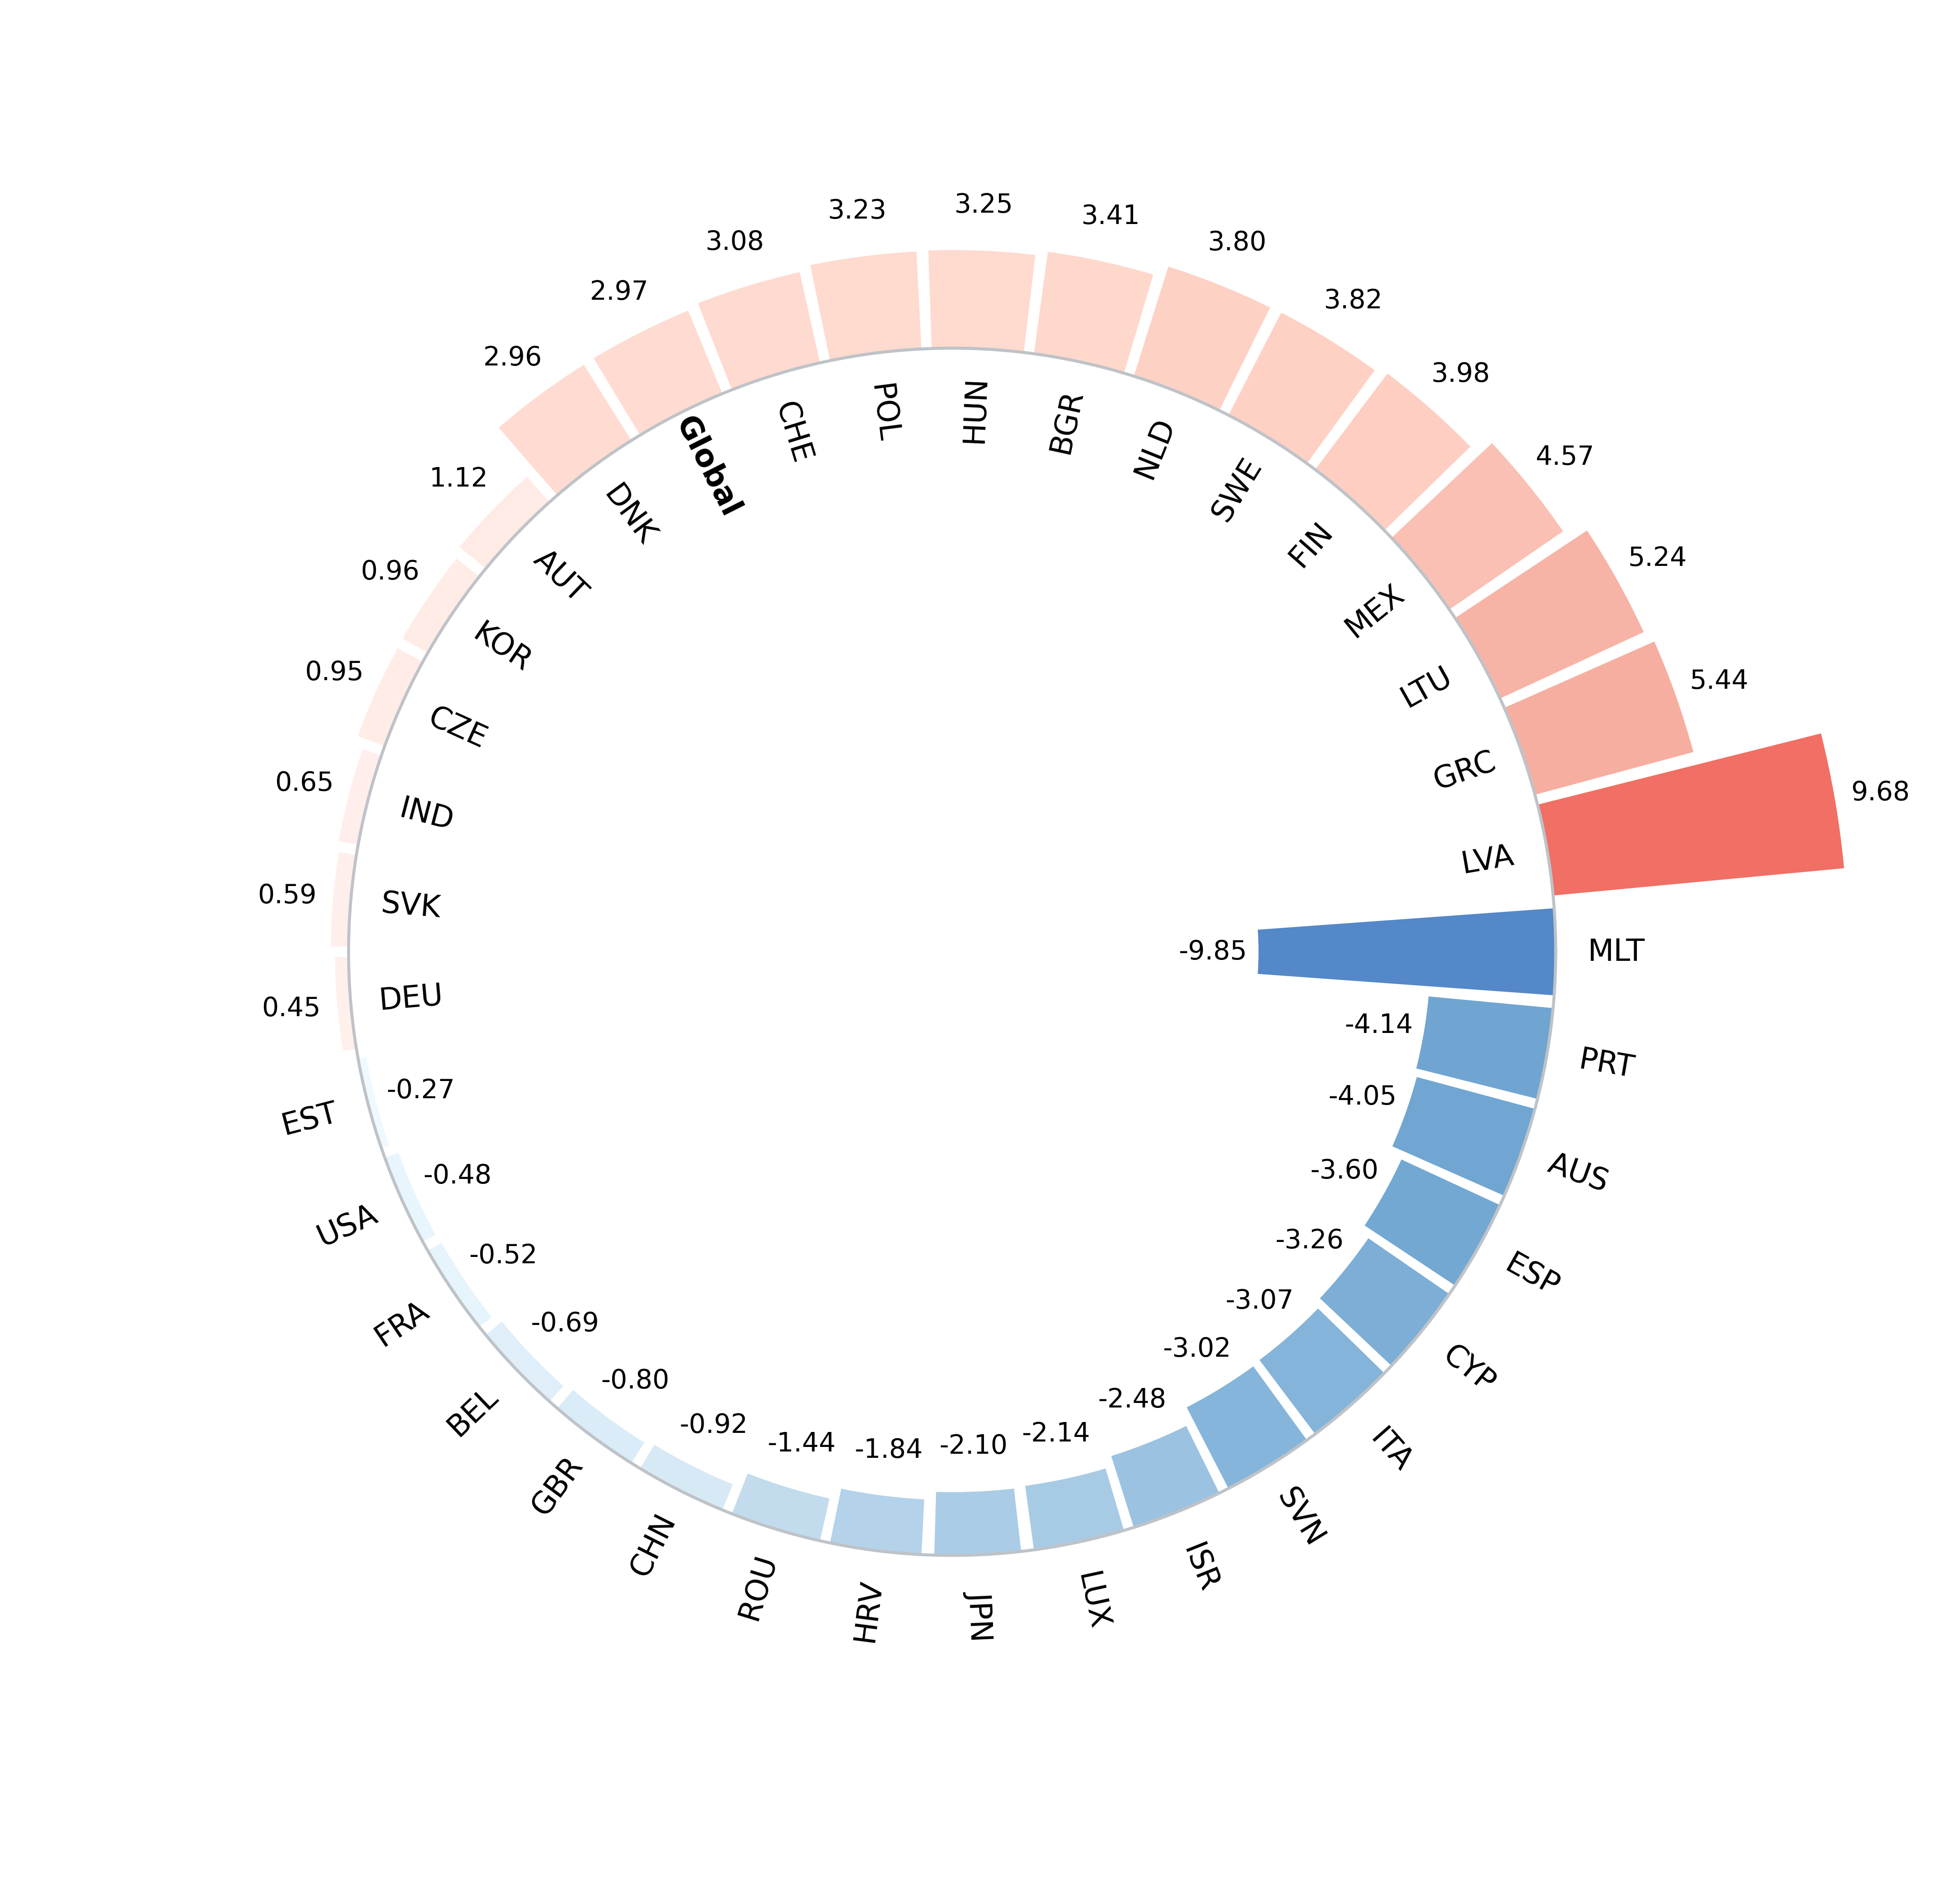

Saved: ../results/f3_CALE/cale_unle_diff_radial.pdf
Countries matched: 37


In [18]:
# CALE - UNLE difference (radial bar, gradient + ISO3 labels)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors, cm

cale = pd.read_csv(CALE_PATH)
cale = cale.rename(columns={"rmst": "CALE", "country": "Country"})
cale = cale[["Country", "CALE"]].dropna()
cale["Country"] = cale["Country"].astype(str).str.strip()
cale["country_norm"] = normalize_country(cale["Country"])

iso_map = load_iso_map(ISO_CSV_PATH)
iso_map["country_norm"] = normalize_country(iso_map["Country"])

last_year = pd.read_csv(LAST_SURVEY_YEAR_PATH)
last_year["country_norm"] = normalize_country(last_year["country"])
last_year["last_survey_year"] = pd.to_numeric(last_year["last_survey_year"], errors="coerce").astype("Int64")
wb = load_wb_unle(WB_UNLE_PATH)

merged = cale.merge(last_year[["country_norm", "last_survey_year"]], on="country_norm", how="inner")
merged = merged.merge(
    wb[["country_norm", "year", "UNLE"]],
    left_on=["country_norm", "last_survey_year"],
    right_on=["country_norm", "year"],
    how="inner",
)
merged = merged.drop(columns=["year"])
# Add Global (CALE from global_popweight_metrics.csv; UNLE from WB 2024)
global_cale = np.nan
if os.path.exists(GLOBAL_METRICS_PATH):
    global_metrics = pd.read_csv(GLOBAL_METRICS_PATH)
    global_mask = global_metrics["country"].astype(str).str.strip().str.lower() == "global"
    if global_mask.any():
        global_cale = pd.to_numeric(global_metrics.loc[global_mask, "rmst"], errors="coerce").iloc[0]
global_unle = get_global_unle(wb, year=2024)
if np.isfinite(global_cale) and np.isfinite(global_unle):
    global_row = pd.DataFrame([{
        "Country": "Global",
        "CALE": float(global_cale),
        "UNLE": float(global_unle),
        "country_norm": "global",
        "last_survey_year": 2024,
    }])
    merged = pd.concat([global_row, merged], ignore_index=True)

merged["DIFF"] = merged["CALE"] - merged["UNLE"]
merged = merged.sort_values("DIFF").reset_index(drop=True)

# ISO3 from iso.csv (country name match)
merged = merged.merge(iso_map[["country_norm", "ISO3"]], on="country_norm", how="left")
merged["ISO3"] = merged["ISO3"].fillna(merged["Country"])
manual_iso3 = {
    "Slovakia": "SVK",
    "Czech Republic": "CZE",
    "England": "GBR",
}
merged["ISO3"] = merged.apply(lambda r: manual_iso3.get(r["Country"], r["ISO3"]), axis=1)
merged["ISO3"] = merged["ISO3"].astype(str).str.upper().str[:3]
merged.loc[merged["Country"].astype(str).str.lower() == "global", "ISO3"] = "Global"

def _polar_label(ax, angle, radius, text, color="black", fs=6, fw="normal"):
    angle_deg = np.degrees(angle)
    screen_angle = 90 - angle_deg
    rotation = screen_angle - 90
    rotation = (rotation + 360) % 360
    if rotation > 180:
        rotation -= 360
    if -90 <= rotation <= 90:
        pass
    else:
        rotation += 180

    ax.text(
        angle,
        radius,
        text,
        rotation=rotation,
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=fs,
        fontweight=fw,
        color=color,
    )

# Radial bar (donut) plot
labels = merged["ISO3"].tolist()
values = merged["DIFF"].to_numpy()

inner_radius = 20
theta = np.linspace(0.0, 2 * np.pi, len(values), endpoint=False)
width = 2 * np.pi / len(values)

# Custom palette: negative vs positive gradients
neg_hex = ["#427CC4", "#528EC6", "#65A0CF", "#EEF9FF"]
pos_hex = ["#FFEFEB", "#FFD3C5", "#F18B7C", "#F06054"]
neg_cmap = mcolors.LinearSegmentedColormap.from_list("custom_neg", neg_hex)
pos_cmap = mcolors.LinearSegmentedColormap.from_list("custom_pos", pos_hex)

colors = np.zeros((len(values), 4))
neg_mask = values < 0
pos_mask = values > 0
if np.any(neg_mask):
    neg_norm = mcolors.Normalize(vmin=values[neg_mask].min(), vmax=values[neg_mask].max())
    colors[neg_mask] = neg_cmap(neg_norm(values[neg_mask]))
if np.any(pos_mask):
    pos_norm = mcolors.Normalize(vmin=values[pos_mask].min(), vmax=values[pos_mask].max())
    colors[pos_mask] = pos_cmap(pos_norm(values[pos_mask]))
colors[~(neg_mask | pos_mask)] = mcolors.to_rgba("#EEF9FF")

widths = np.full(len(values), width * 0.9)
for code in ["JPN", "MLT"]:
    if code in labels:
        widths[labels.index(code)] = width * 0.85

fig = plt.figure(figsize=(7.2, 7.2), dpi=DPI_OUT)
fig.patch.set_facecolor("none")
fig.patch.set_alpha(0.0)
ax = fig.add_subplot(111, projection="polar")
ax.set_facecolor("none")
ax.set_theta_direction(-1)
ax.set_theta_offset(0.0)
ax.bar(theta, values, width=widths, bottom=inner_radius, color=colors, alpha=0.9)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.grid(False)
ax.spines["polar"].set_visible(False)

r_max = inner_radius + np.max(np.abs(values)) + 0.8
ax.set_ylim(0, r_max)

# Zero line for DIFF = 0
theta_dense = np.linspace(0.0, 2 * np.pi, 360)
ax.plot(theta_dense, np.full_like(theta_dense, inner_radius), color="#BEC3C8", linewidth=0.8)

# ISO3 labels around the zero tick line
for ang, name, v in zip(theta, labels, values):
    label_r = inner_radius - 2 if v >= 0 else inner_radius + 2
    label_weight = "bold" if str(name).strip().lower() == "global" else "normal"
    _polar_label(ax, ang, label_r, name, color="#000000", fs=FONT_SIZE-1, fw=label_weight)

# Value labels 1 cm away from bar tips (radial direction)
fig_w, fig_h = fig.get_size_inches()
bbox = ax.get_position()
ax_w = fig_w * bbox.width
ax_h = fig_h * bbox.height
radius_in = min(ax_w, ax_h) / 2.0
cm_in = 0.35 / 2.54
r_range = ax.get_rmax() - ax.get_rmin()
offset_r = cm_in / radius_in * r_range
for ang, v in zip(theta, values):
    tip_r = inner_radius + v
    offset = offset_r if v >= 0 else -offset_r
    ax.text(ang, tip_r + offset, f"{v:.2f}", fontsize=FONT_SIZE - 2, ha="center", va="center")

out_path = os.path.join(OUT_DIR, "cale_unle_diff_radial.pdf")
plt.tight_layout()
plt.savefig(out_path, dpi=DPI_OUT, bbox_inches="tight", pad_inches=0, facecolor="none", edgecolor="none", transparent=True)
plt.show()
print("Saved:", out_path)

print("Countries matched:", len(merged))

In [ ]:
# Country CALE confidence interval dumbbell plot
cale_ci = pd.read_csv(CALE_PATH).copy()
cale_ci = cale_ci.rename(columns={"country": "Country", "rmst": "CALE"})
needed = ["Country", "continent", "CALE", "rmst_lcl", "rmst_ucl"]
missing = [c for c in needed if c not in cale_ci.columns]
if missing:
    raise ValueError(f"Missing columns for CALE CI plot: {missing}")

cale_ci = cale_ci[needed].copy()
for c in ["CALE", "rmst_lcl", "rmst_ucl"]:
    cale_ci[c] = pd.to_numeric(cale_ci[c], errors="coerce")
cale_ci = cale_ci.dropna(subset=["Country", "CALE", "rmst_lcl", "rmst_ucl"])
cale_ci["Country"] = cale_ci["Country"].astype(str).str.strip()
cale_ci["country_norm"] = normalize_country(cale_ci["Country"])

last_year = pd.read_csv(LAST_SURVEY_YEAR_PATH)
last_year["country_norm"] = normalize_country(last_year["country"])
last_year["last_survey_year"] = pd.to_numeric(last_year["last_survey_year"], errors="coerce").astype("Int64")

cale_ci = cale_ci.merge(
    last_year[["country_norm", "last_survey_year"]],
    on="country_norm",
    how="left",
)
cale_ci["survey_year"] = cale_ci["last_survey_year"].astype("Int64")

# Add Global with global-population-weighted CALE and CI.
if os.path.exists(GLOBAL_METRICS_PATH):
    global_metrics = pd.read_csv(GLOBAL_METRICS_PATH)
    global_mask = global_metrics["country"].astype(str).str.strip().str.lower() == "global"
    if global_mask.any():
        g = global_metrics.loc[global_mask].iloc[0]
        global_row = pd.DataFrame([{
            "Country": "Global",
            "continent": "Global",
            "CALE": pd.to_numeric(g.get("rmst"), errors="coerce"),
            "rmst_lcl": pd.to_numeric(g.get("rmst_lcl"), errors="coerce"),
            "rmst_ucl": pd.to_numeric(g.get("rmst_ucl"), errors="coerce"),
            "country_norm": "global",
            "last_survey_year": pd.NA,
            "survey_year": 2024,
        }])
        cale_ci = pd.concat([global_row, cale_ci], ignore_index=True)

cale_ci = cale_ci.dropna(subset=["CALE", "rmst_lcl", "rmst_ucl"])
cale_ci = cale_ci.sort_values(["survey_year", "Country"], ascending=[False, True]).reset_index(drop=True)
global_idx = cale_ci["Country"].astype(str).str.lower().eq("global")
if global_idx.any():
    global_row = cale_ci.loc[global_idx]
    cale_ci = pd.concat([global_row, cale_ci.loc[~global_idx]], ignore_index=True)
cale_ci["display_name"] = cale_ci["Country"].astype(str).str.strip() + " (" + cale_ci["survey_year"].astype("Int64").astype(str) + ")"

continent_palette = {
    "Europe": "#D07A55",
    "Asia": "#C64E71",
    "North America": "#8F6EB8",
    "Oceania": "#3E83C7",
    "Global": "#2AA6B0",
}
line_color = "#C5CED6"
text_color = "#343A40"


def _cale_lighten_color(hex_color: str, factor: float = 0.65) -> str:
    rgb = np.array(plt.matplotlib.colors.to_rgb(hex_color))
    return plt.matplotlib.colors.to_hex(rgb + (1 - rgb) * factor)

n = len(cale_ci)
fig_h = max(7.0, 0.25 * n + 1.2)
fig, ax = plt.subplots(figsize=(7.9, fig_h), dpi=DPI_OUT)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y = np.arange(n)
for i, row in cale_ci.iterrows():
    continent = row.get("continent", "")
    is_global = str(row["Country"]).strip().lower() == "global"
    color = continent_palette.get(continent, "#4B5563")
    lcl = float(row["rmst_lcl"])
    ucl = float(row["rmst_ucl"])

    if i % 2 == 0:
        ax.axhspan(i - 0.42, i + 0.42, color="#F7F8FA", zorder=0)
    ax.hlines(i, lcl, ucl, color=color if is_global else line_color, linewidth=1.25, alpha=0.95, zorder=1)
    low_color = _cale_lighten_color(color, factor=0.68)
    high_color = color
    ax.scatter(
        lcl, i,
        s=30 if is_global else 24,
        facecolor=low_color,
        edgecolor=low_color,
        linewidth=0.4,
        zorder=3,
    )
    ax.scatter(
        ucl, i,
        s=30 if is_global else 24,
        facecolor=high_color,
        edgecolor=high_color,
        linewidth=0.4,
        zorder=3,
    )
    ax.text(
        lcl - 0.14,
        i,
        f"{lcl:.2f}",
        va="center",
        ha="right",
        fontsize=6.4,
        color=color if is_global else text_color,
        fontweight="bold" if is_global else "normal",
    )
    ax.text(
        ucl + 0.14,
        i,
        f"{ucl:.2f}",
        va="center",
        ha="left",
        fontsize=6.4,
        color=color if is_global else text_color,
        fontweight="bold" if is_global else "normal",
    )

ax.set_yticks(y)
ax.set_yticklabels(cale_ci["display_name"], fontsize=7)
ax.set_xlabel("CALE (years)", fontsize=9)
ax.set_ylabel("")

xmin = np.floor(cale_ci["rmst_lcl"].min() - 2)
xmax = np.ceil(cale_ci["rmst_ucl"].max() + 2)
ax.set_xlim(xmin, xmax)
ax.set_ylim(n - 0.45, -0.55)
ax.xaxis.grid(True, color="#E5E7EB", linewidth=0.55)
ax.yaxis.grid(False)
ax.tick_params(axis="x", labelsize=7, width=0.5, length=3, color="#6B7280")
ax.tick_params(axis="y", width=0.0, length=0)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_linewidth(0.55)
ax.spines["bottom"].set_color("#6B7280")

legend_handles = []
for continent, color in continent_palette.items():
    if continent in set(cale_ci["continent"].dropna()):
        legend_handles.append(
            plt.Line2D(
                [0], [0], marker="o", color="none", markerfacecolor=color,
                markeredgecolor=color, markeredgewidth=0.7, markersize=4.6, label=continent
            )
        )
if legend_handles:
    ax.legend(handles=legend_handles, frameon=False, fontsize=7, loc="lower right", handletextpad=0.4)

plt.tight_layout()
out_pdf = os.path.join(OUT_DIR, "country_cale_ci_dumbbell.pdf")
fig.savefig(out_pdf, dpi=DPI_OUT, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved:", out_pdf)
